### langchain version v1

In [1]:
import langchain
langchain.__version__

'1.3.18'

load_dotenv = Reads all the KEY=VALUE pairs inside that file <br> don't keep space while linking the api line

In [ ]:

import os
from dotenv import  load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")




def weather(city:str)->str means city should be string and function return in string form

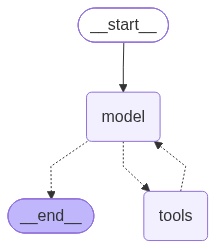

In [6]:

# creating basic LLM agent

from langchain.agents import create_agent


def weather(city:str)->str:
    """ this about city """
    return f" the weather of {city} city is good : "


agent = create_agent(
    model = "gpt-5",
    tools = [weather],
    system_prompt = "it is best api assistant : "
)
agent

In [9]:

# for agent running 

agent.invoke({"messages":[{"role":"user","content":"what is the weather of kathmadu : "}]})

{'messages': [HumanMessage(content='what is the weather of kathmadu : ', additional_kwargs={}, response_metadata={}, id='68337e3b-5457-4b24-b245-be2135b995b3'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 215, 'prompt_tokens': 141, 'total_tokens': 356, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EI3rh8rqIT0nKpvcZ3tYCsXmjVvXI', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a04b85-ff0a-7781-843d-5de7e3f36e04-0', tool_calls=[{'name': 'weather', 'args': {'city': 'Kathmandu'}, 'id': 'call_PNMUcGdhK8OyHgoG4GRtI6dA', 'typ

In [11]:

respone = agent.invoke({'messages':[{'role':'user','content':'what is the weather of kathmandu '}]})
respone["messages"][-1].content

'The weather in Kathmandu is good.\n\nWould you like details such as temperature, precipitation, wind, or a multi‑day forecast?'

In [14]:

#  another way of asking question 

agent.invoke({'messages':'what is the weather of pokhara'})

{'messages': [HumanMessage(content='what is the weather of pokhara', additional_kwargs={}, response_metadata={}, id='90eaa596-6eae-4173-9e5f-da3d19991f36'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 138, 'total_tokens': 289, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EI40GL5I19sZPgi14EnUHCQ4j81iG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a04b8e-1a46-7632-ba47-cb79130e4b36-0', tool_calls=[{'name': 'weather', 'args': {'city': 'Pokhara'}, 'id': 'call_kzbWboF2dnvEZHRGpPEqscQU', 'type': 't

Add a docstring inside every function that you use as a tool. it play important role in making answer

In [31]:

## practising one more example 

from langchain.agents import create_agent

def fruits(name:str)->str:
    """use this tool when there is about fruits"""
    return f"{name} is very good for health :"

def machine(name:str)->str:
    """use this tool when user ask about machine  or equipement uses : """
    return f"{name}  make our life easier : "


agents = create_agent(
    model='gpt-5',
    tools=[fruits,machine],
    system_prompt = "this api is good for learning"
)

res = agents.invoke({"messages":[{"role":"user","content":"what is the use of apple"}]})

res["messages"][-2].content


#  user '' this for to give message


'apple is very good for health :'

In [34]:


respone = agents.invoke({'messages':'what is the use of computer '})
respone["messages"][-2].content



'computer  make our life easier : '


### Models intergration with OpenAi,goole ai , grooq


In [38]:

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


### Model intergation with openai

In [ ]:

from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-4.1")
mess = model.invoke("hello how are you ? ")
mess.content


'Hello! I’m just a virtual assistant, so I don’t have feelings, but I’m here and ready to help you. How can I assist you today?'

In [46]:
### another way to modeling

from langchain_openai import  ChatOpenAI

model = ChatOpenAI(model = "gpt-4.1")

mss = model.invoke("How are you ?")
mss.content

'I’m just a bunch of code, so I don’t have feelings, but I’m here and ready to help! How can I assist you today?'


### Model intergation with google api 

In [ ]:

import os 

from langchain.chat_models import  init_chat_model

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

model = init_chat_model("google_genai:gemini-3.5-flash")

google_mess = model.invoke("what is the use of computer ?")
google_mess.text



'Computers have become an essential part of modern life. They are used in almost every aspect of human activity, from personal daily tasks to complex scientific research. \n\nHere is a breakdown of the primary uses of computers, categorized by field:\n\n---\n\n### 1. Education\n* **Online Learning:** Accessing e-learning platforms, virtual classrooms (like Zoom or Google Classroom), and educational websites.\n* **Research:** Searching the internet for information, scientific papers, and digital libraries.\n* **Administrative Work:** Managing student databases, grading systems, and creating report cards.\n\n### 2. Business and Office Work\n* **Data Management:** Storing and organizing massive amounts of data using spreadsheets (Excel) and databases.\n* **Communication:** Sending emails, conducting video conferences, and using instant messaging apps like Slack or Microsoft Teams.\n* **Accounting and Finance:** Managing payrolls, invoicing, tax calculations, and tracking expenses.\n* **Ma

In [54]:

### another way to intergation 

import os 

from langchain_google_genai import  GoogleGenerativeAI

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

model = GoogleGenerativeAI(model="gemini-3.5-flash")

google_mess = model.invoke("what is the use of pen ?")
google_mess



'Although we live in a highly digital world, the **pen** remains one of the most important and versatile tools ever invented. Its primary purpose is to apply ink to a surface (usually paper) to record thoughts, but its uses span across communication, art, psychology, and daily utility. \n\nHere is a comprehensive breakdown of the uses of a pen:\n\n---\n\n### 1. Communication and Record-Keeping\n*   **Writing and Note-Taking:** The most common use. Students use pens to take notes in class, and professionals use them to jot down minutes of meetings, phone numbers, or quick ideas.\n*   **Filling Out Forms:** From government documents and medical intake forms to customs declarations, many official processes still require physical paperwork filled out in ink.\n*   **Personal Correspondence:** Writing letters, thank-you notes, and greeting cards by hand adds a personal, thoughtful touch that emails and texts cannot replicate.\n\n### 2. Legal and Professional Use\n*   **Signatures:** Contract


### Model integration with grop ai

In [58]:

import os
from langchain.chat_models import  init_chat_model

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:openai/gpt-oss-20b")

mss = model.invoke("what is the capital city of nepal : ")
mss.content

'The capital city of Nepal is **Kathmandu**.'

In [6]:

import os 

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(model="openai/gpt-oss-20b")

mss = model.invoke("what is the capital city of nepali : ")
mss.content



'The capital city of Nepal is **Kathmandu**.'


### Streaming and Batch


### Streaming

Streaming: Streaming means getting the AI model’s response little by little as it is generated, instead of waiting for the complete answer. It is useful for chat applications because the user can see the response immediately.

In [7]:
### creating modeling  

import os 
from langchain_openai import  ChatOpenAI

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

models = ChatOpenAI(model="gpt-4.1")

mss = models.invoke("write the paragraph about the Myvillage ? about(200 words)")
mss.content

'Certainly! Here is a 200-word paragraph about "My Village":\n\nMy village is a peaceful and charming place nestled among lush green fields and rolling hills. It is a small community where everyone knows each other and people live in close harmony with nature. The air is fresh and clean, filled with the sweet fragrance of blooming flowers and ripe fruits from the orchards. In the mornings, the sound of birds chirping gently wakes me up, and the view of the sunrise over the distant mountains is breathtaking. Most people in my village are farmers, and agriculture is the main occupation here. The fields are filled with crops like rice, wheat, and vegetables, which make the landscape look vibrant and lively throughout the year. Besides farming, some villagers are skilled in traditional crafts, adding cultural richness to our community. There is a small school, a health center, and a temple, which are at the heart of village life. Festivals are celebrated with great enthusiasm, bringing tog

4. flush=True

Normally, Python may temporarily store the output in a buffer before displaying it. it say to display it immediately 

In [8]:

### with using stream 

for i in models.stream("write the paragraph about the Myvillage ? about(200 words)"):
    print(i.text.replace(".","\n"),end="",flush=True)

My village is a peaceful and beautiful place surrounded by lush green fields and tall trees
 It is located away from the hustle and bustle of the city, making it an ideal place to live for those who love nature and tranquility
 The atmosphere is fresh and pollution-free, with birds chirping in the morning and cool breezes blowing throughout the day
 The people in my village are friendly, hardworking, and always ready to help each other
 Most of the villagers are farmers who grow crops like wheat, rice, and vegetables
 There is a small river that flows on one side of the village, adding to its scenic beauty
 My village has a primary school where children receive their basic education, and a small health center that provides medical care to the villagers
 Festivals and traditional events are celebrated with great enthusiasm, bringing everyone together in the spirit of unity and joy
 The houses are simple but neat, mostly made of bricks and mud
 Life in my village is simple and peaceful, 

In [24]:

#  another example of stream

for i in models.stream("What is use of of computer ? ans me in point (5)"):
    print(i.text,end="",flush=True)

**Use of Computer:**

1. **Data Storage:** Computers are used to store large amounts of data securely and efficiently.
2. **Internet Access:** They allow users to browse the internet, send emails, and access information online.
3. **Education:** Computers are widely used for online learning, research, and preparing educational materials.
4. **Entertainment:** They are used for watching movies, listening to music, playing games, and creating digital art.
5. **Business Operations:** Computers help in managing accounts, creating documents, making presentations, and running various business software.


### Batch 
Batch: Batch means sending multiple inputs together to the model and getting their results. It is useful when you need to process many requests at the same time, such as summarizing multiple documents.

In [28]:

answer_list = models.batch([
    'what is capital city of nepal ?',
    'write simple paragraph of that city(kathmandu) ?',
    'how many caste of people live in nepal ?',
    'do not show additional information'
])

for i in answer_list:
    print(i.text)

The capital city of Nepal is **Kathmandu**.
Kathmandu is the capital city of Nepal and is known for its rich history and vibrant culture. It is located in a beautiful valley surrounded by hills and mountains. The city is famous for its ancient temples, colorful markets, and friendly people. Tourists visit Kathmandu to see famous sites like Swayambhunath (the Monkey Temple), Pashupatinath, and Durbar Square. Despite being busy and crowded, Kathmandu has a unique charm that attracts visitors from all over the world.
Nepal is a country with rich ethnic and cultural diversity. There is **no single fixed number** of castes in Nepal, as the number can vary depending on classification methods, sources, and the detailed lists maintained by the government.

### Main Points:

- **Ethnic Groups/Ethno-Caste Groups**: Nepal's population consists of **more than 125 caste and ethnic groups** as per the **2011 census** (Central Bureau of Statistics, Nepal).
- **Caste System**: Broadly, the caste syste

In [11]:


### batches with configuration 

mss = models.batch([
    'about dog',
    'about cat',
    'about anima'
],
config={
    'max_concurrency':2,
}
)

mss

[AIMessage(content='Certainly! Here’s an overview about **dogs**:\n\n---\n\n## What is a Dog?\n\nA **dog** (*Canis lupus familiaris*) is a domesticated mammal and a subspecies of the gray wolf. Dogs have been bred by humans for thousands of years for various traits including companionship, work, hunting, and herding.\n\n---\n\n## General Characteristics\n\n- **Lifespan:** 10–15 years (varies by breed)\n- **Size:** Ranges from tiny breeds (like Chihuahuas) to very large (like Great Danes)\n- **Diet:** Omnivorous (though some breeds have specific dietary needs)\n- **Intelligence:** Dogs are highly intelligent and trainable\n- **Communication:** They communicate through barking, body language, and facial expressions\n\n---\n\n## Common Roles\n\n- **Companions:** Pets and family members\n- **Working Dogs:** Herding, hunting, guarding, policing, guiding for the visually impaired, therapy\n- **Rescue Dogs:** Search and rescue, disaster response\n\n---\n\n## Popular Breeds\n\nExamples include